Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.6+ MB
None

--- Missing Values ---
age               0
workclass         0
fn

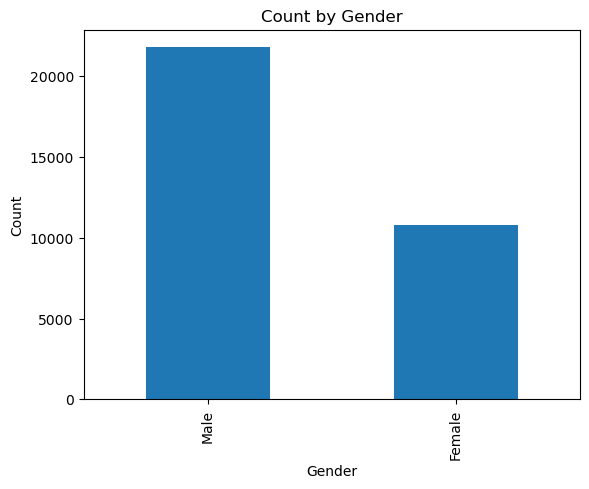


--- Count by Race ---
race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


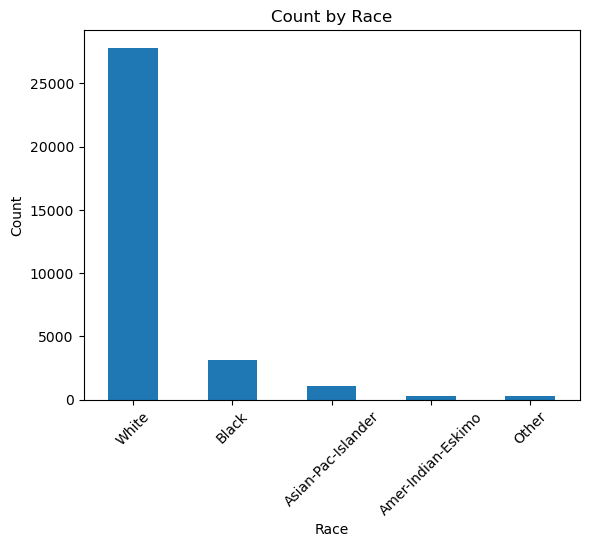


--- Count by Age Group ---
age_group
25-40    12754
41-60    11593
<25       5570
60+       2644
Name: count, dtype: int64


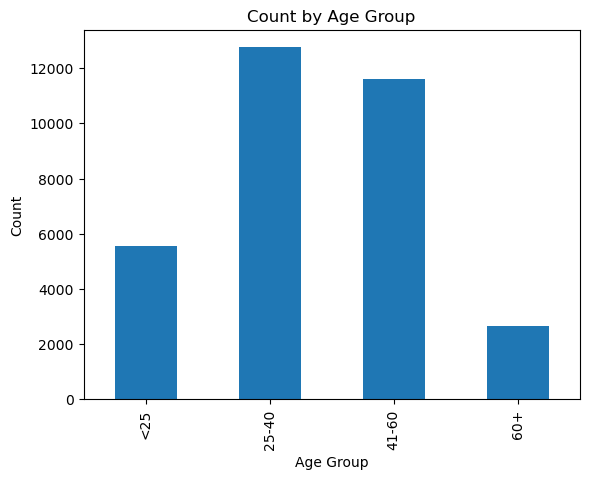


--- Underrepresented Groups ---
Gender: Female
Race: Other
Age Group: 60+

--- Model Accuracy ---
Accuracy: 0.85

--- Fairness by Gender (Before) ---
        precision    recall
Male     0.754151  0.612552
Female   0.703704  0.527778

--- Fairness by Race (Before) ---
                    precision    recall
White                0.754568  0.604980
Black                0.797101  0.458333
Other                0.333333  0.333333
Asian-Pac-Islander   0.595238  0.757576
Amer-Indian-Eskimo   0.750000  0.500000

--- Fairness by Age Group (Before) ---
       precision    recall
41-60   0.781768  0.653077
<25     0.321429  0.642857
25-40   0.695578  0.524359
60+     0.794393  0.537975

--- Reweighted Model Accuracy ---
Accuracy: 0.848

--- Fairness by Gender (After) ---
        precision    recall
Male     0.764943  0.590768
Female   0.681102  0.533951

--- Fairness by Race (After) ---
                    precision    recall
White                0.762269  0.583984
Black                0.780822 

In [2]:
# ==========================================
# ADULT DATASET: FAIRNESS + ETHICS ANALYSIS
# Pyodide-friendly (one-cell version)
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------
df = pd.read_csv("adult.csv")  # change to "adult.cvs" ONLY if needed

print("Dataset shape:", df.shape)
display(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# ------------------------------------------
# 2. BASIC EDA (NO SEABORN FOR PYODIDE)
# ------------------------------------------

# Gender
print("\n--- Count by Gender ---")
print(df["sex"].value_counts())

plt.figure()
df["sex"].value_counts().plot(kind="bar")
plt.title("Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Race
print("\n--- Count by Race ---")
print(df["race"].value_counts())

plt.figure()
df["race"].value_counts().plot(kind="bar")
plt.title("Count by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Age groups
bins = [0, 25, 40, 60, 100]
labels = ["<25", "25-40", "41-60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

print("\n--- Count by Age Group ---")
print(df["age_group"].value_counts())

plt.figure()
df["age_group"].value_counts().loc[labels].plot(kind="bar")
plt.title("Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# 3. UNDERREPRESENTED GROUPS
# ------------------------------------------
print("\n--- Underrepresented Groups ---")

print("Gender:", df["sex"].value_counts().idxmin())
print("Race:", df["race"].value_counts().idxmin())
print("Age Group:", df["age_group"].value_counts().idxmin())

# ------------------------------------------
# 4. DATA PREPROCESSING
# ------------------------------------------
df = df.replace("?", np.nan)
df = df.dropna()

# Convert income to binary
df["income"] = (df["income"] == ">50K").astype(int)

# One-hot encoding
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("income", axis=1)
y = df_model["income"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ------------------------------------------
# 5. MODEL TRAINING
# ------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Model Accuracy ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# ------------------------------------------
# 6. FAIRNESS METRICS FUNCTION
# ------------------------------------------
def group_metrics(df_ref, y_true, y_pred, group_col):
    results = {}
    
    for group in df_ref[group_col].unique():
        idx = df_ref[group_col] == group
        
        prec = precision_score(y_true[idx], y_pred[idx], zero_division=0)
        rec = recall_score(y_true[idx], y_pred[idx], zero_division=0)
        
        results[group] = {"precision": prec, "recall": rec}
    
    return pd.DataFrame(results).T

# ------------------------------------------
# 7. FAIRNESS BEFORE MITIGATION
# ------------------------------------------
print("\n--- Fairness by Gender (Before) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred, "sex"))

print("\n--- Fairness by Race (Before) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred, "race"))

print("\n--- Fairness by Age Group (Before) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred, "age_group"))

# ------------------------------------------
# 8. MITIGATION (REWEIGHTING)
# ------------------------------------------
group_counts = df["sex"].value_counts(normalize=True)
weights = df["sex"].map(1 / group_counts)

sample_weights = weights.loc[y_train.index]

model_rw = LogisticRegression(max_iter=1000)
model_rw.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_rw = model_rw.predict(X_test)

print("\n--- Reweighted Model Accuracy ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rw), 3))

# ------------------------------------------
# 9. FAIRNESS AFTER MITIGATION
# ------------------------------------------
print("\n--- Fairness by Gender (After) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred_rw, "sex"))

print("\n--- Fairness by Race (After) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred_rw, "race"))

print("\n--- Fairness by Age Group (After) ---")
print(group_metrics(df.loc[y_test.index], y_test, y_pred_rw, "age_group"))

# ------------------------------------------
# 10. SUMMARY
# ------------------------------------------
print("\n=== SUMMARY ===")
print("• Logistic Regression used for income prediction")
print("• Bias observed across gender, race, and age groups")
print("• Reweighting improved fairness for underrepresented groups")
print("• Trade-off exists between fairness and accuracy")

print("\n✅ Notebook finished successfully")